In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.data import create_generators
from src.model import build_model
from src.train import train_model
from src.evaluate import evaluate_model
from src.visualize import show_portfolio
from src.config import *
  


In [4]:
#Load data

train_gen, val_gen, test_gen = create_generators(
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR
)

Found 280 images belonging to 4 classes.
Found 60 images belonging to 4 classes.
Found 60 images belonging to 4 classes.


In [5]:
#Build the model

model = build_model(NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
#Train the model

history = train_model(model, train_gen, val_gen)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.9179 - loss: 0.2470 - val_accuracy: 0.9333 - val_loss: 0.2546
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.9179 - loss: 0.2551 - val_accuracy: 0.9167 - val_loss: 0.2806
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.9500 - loss: 0.2061 - val_accuracy: 0.9333 - val_loss: 0.2626
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 234ms/step - accuracy: 0.9429 - loss: 0.2057 - val_accuracy: 0.9167 - val_loss: 0.2488
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - accuracy: 0.9429 - loss: 0.2141 - val_accuracy: 0.9333 - val_loss: 0.2318
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.9464 - loss: 0.1856 - val_accuracy: 0.9333 - val_loss: 0.2224
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 232ms/step - accuracy: 0.9357 - loss: 0.1929 - val_accuracy: 0.9333 - val_loss: 0.2240
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - accuracy: 0.9179 - loss: 0.2057 - val_accuracy: 0.

In [8]:
#Evaluate the model

evaluate_model(model, test_gen)

Starting evaluation...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 270ms/step

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.72      0.87      0.79        15
           2       1.00      1.00      1.00        15
           3       0.83      0.67      0.74        15

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60


Results saved to: models/results_20260302_211113.json
Confusion matrix saved to: models/confusion_matrix_20260302_211113.png


(0.8833333333333333,
 {'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 15.0},
  '1': {'precision': 0.7222222222222222,
   'recall': 0.8666666666666667,
   'f1-score': 0.7878787878787878,
   'support': 15.0},
  '2': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 15.0},
  '3': {'precision': 0.8333333333333334,
   'recall': 0.6666666666666666,
   'f1-score': 0.7407407407407407,
   'support': 15.0},
  'accuracy': 0.8833333333333333,
  'macro avg': {'precision': 0.888888888888889,
   'recall': 0.8833333333333333,
   'f1-score': 0.8821548821548821,
   'support': 60.0},
  'weighted avg': {'precision': 0.888888888888889,
   'recall': 0.8833333333333333,
   'f1-score': 0.8821548821548821,
   'support': 60.0}},
 array([[15,  0,  0,  0],
        [ 0, 13,  0,  2],
        [ 0,  0, 15,  0],
        [ 0,  5,  0, 10]]))

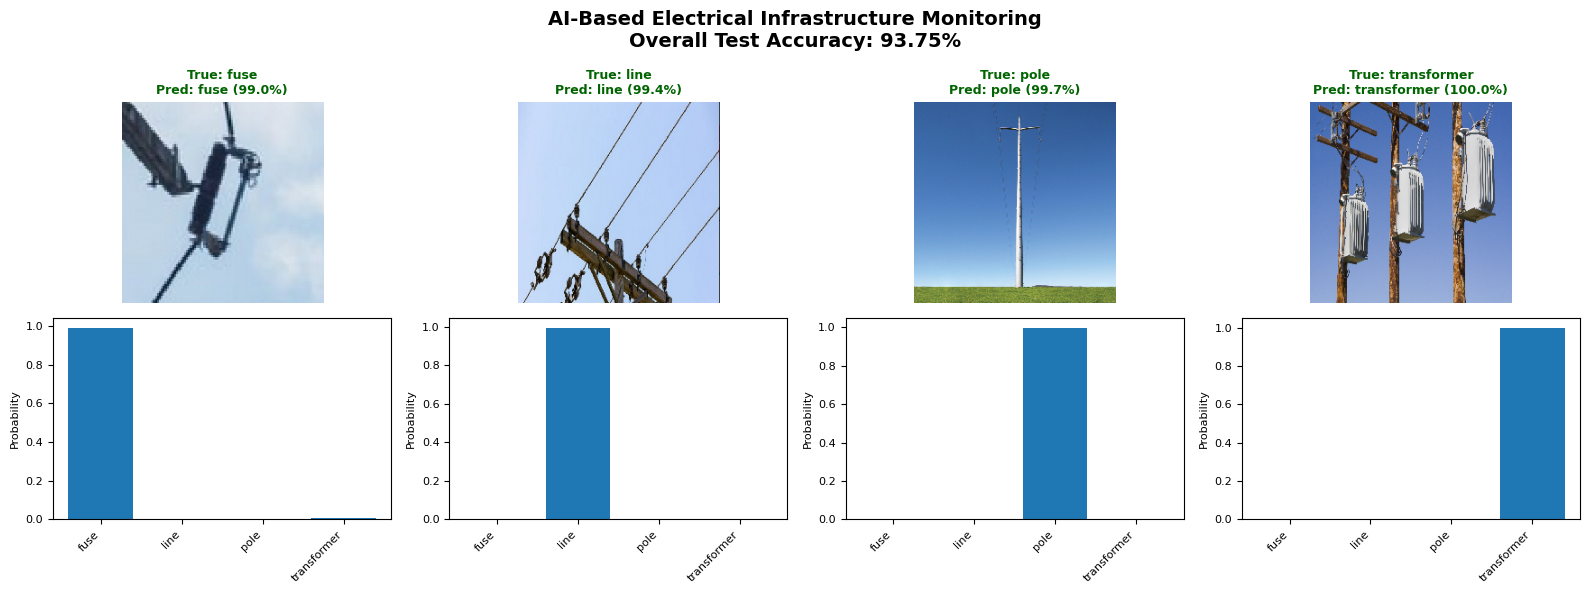

Professional IEEE-style figure saved as: Sample per class.png


In [9]:

show_portfolio(model, test_gen)